## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [3]:
# Path to load the data

# Amélie
# link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
link = r"E:\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [4]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'zigzag':
                list_of_actions = F.move
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            print(list_of_rewards)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

Episode:  0
Time | ep_step:  0 0


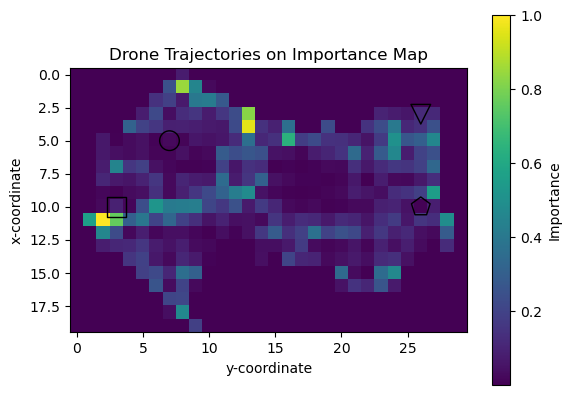

[3.332693861797452, -1.5609251931309698, 1.200954738462543, -0.9187176283448933]
Time | ep_step:  1 1
[0.9101563245058053, 0.18797259777784348, -8.95087555423379, 4.037587456405162]
Time | ep_step:  2 2
[1.5319312773644933, 1.3360572462698883, 6.5498824743554, 1.8913366161286838]
Time | ep_step:  3 3
[0.022104140371084213, 0.19302770752372522, 8.7232125108892, -0.19794715866446544]
Time | ep_step:  4 4
[18.49169707596302, 2.2406944888846505, 1.3813928244635443, 9.247069621831178]
-----------
Episode:  1
Time | ep_step:  5 0
[-18.58242231361568, 12.476151089298282, -5.245468660257757, -11.271555107980966]
Time | ep_step:  6 1
[19.68468272209168, 6.301276261918247, 4.971950665505803, 6.659523363262415]
Time | ep_step:  7 2
[-19.535115998119117, -8.26070599425584, 1.8611228553747883, 3.120795497298242]
Time | ep_step:  8 3
[18.84113317684084, -6.754092033133752, 2.528743948005172, -3.7897078647464517]
Time | ep_step:  9 4
[-18.292398348010334, 3.724029167312427, 4.171067340464589, -1.3706

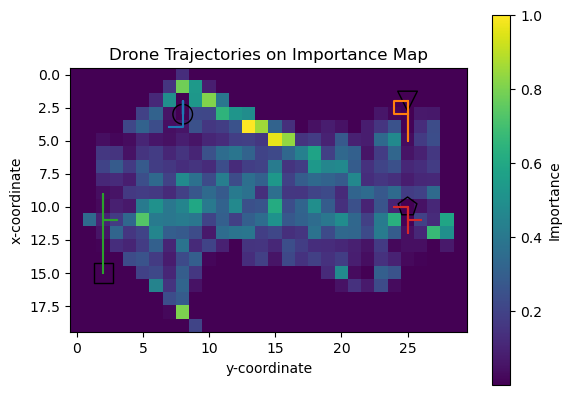

[18.308288694629443, 8.177801985708514, 4.25, 11.794765545092522]
Time | ep_step:  11 1
[-17.97118533527061, -0.36250922499997784, 4.25, 2.029921776928009]
Time | ep_step:  12 2
[17.60400556040026, 0.48750010000000044, 4.25, -2.922116913832723]
Time | ep_step:  13 3
[-17.319112404274122, 5.5125027749999935, -0.7500099999999743, 2.8539030412212005]
Time | ep_step:  14 4
[17.57980046606676, -1.437511124999971, 0.8750008749999969, -2.4520587824806572]
-----------
Episode:  3
Time | ep_step:  15 0
[-17.42946390917995, 1.5625024999999937, 0.3749996750000017, 2.1887520187124614]
Time | ep_step:  16 1
[16.764438517012216, 2.2496245973852615, 1.062500599999998, -2.0576036798805015]
Time | ep_step:  17 2
[-16.342656739944896, 7.986406956803016, 1.2875006, 2.30200119529292]
Time | ep_step:  18 3
[16.614430427920517, 8.252276952512815, 1.7481830031734558, -1.6658235534429555]
Time | ep_step:  19 4
[-16.218765972020112, 6.8946092201396825, 4.277282197030993, 1.310579407191836]
-----------
Episode:

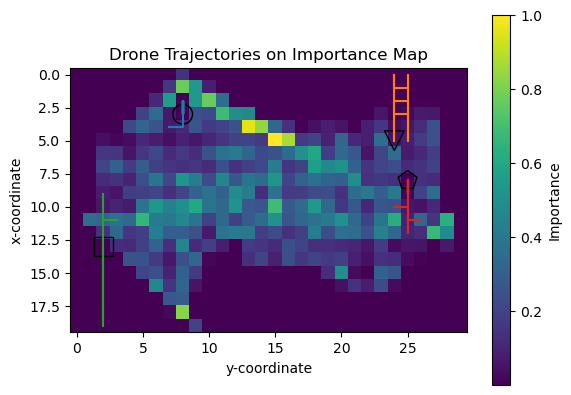

[15.965447999195066, 4.122264336794615, 5.8174578188904125, -1.0129148338509735]
Time | ep_step:  21 1
[-15.684667819951905, 3.8012000173330316, 1.5117291429841795, 0.7940348231756128]
Time | ep_step:  22 2
[15.2008951057892, -0.07851464483151216, -1.6561455092223243, 3.812729360857103]
Time | ep_step:  23 3
[-15.174237558237824, 2.8028987978578934, 4.234249218273907, -0.4731596482742395]
Time | ep_step:  24 4
[16.620753357085785, 9.52829582329955, 6.3979981049895285, 4.80861598065679]
-----------
Episode:  5
Time | ep_step:  25 0
[-16.20773423980811, 3.1839973210468884, 5.4306179136037835, 3.2825619671842183]
Time | ep_step:  26 1
[15.640081838178475, 2.9553408263623715, 1.84476593323052, 2.6986349545419235]
Time | ep_step:  27 2
[-0.5073209801079481, -1.6505838213860962, 2.1622460050678005, -3.4434370588511247]
Time | ep_step:  28 3
[-14.74543611562526, 4.592054548338054, 3.844974287934634, -0.12456976037098083]
Time | ep_step:  29 4
[3.9830437564802446, 4.681248356977676, 4.19915013

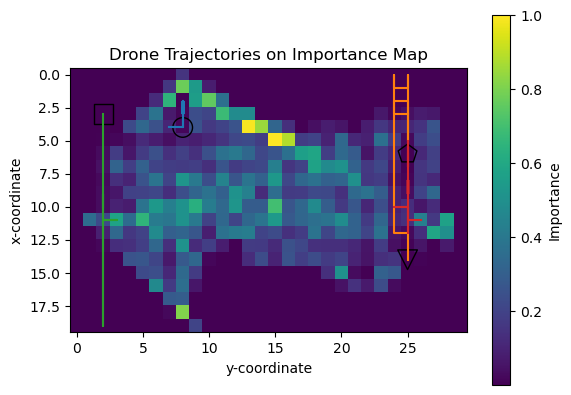

[3.9695216149504935, 5.358075240775975, 4.25, -0.012207174915410679]
Time | ep_step:  31 1
[5.717493078485132, 1.7235423709985587, 4.25, 0.83198718105922]
Time | ep_step:  32 2
[8.63890246115625, 3.947283224592184, -0.7500099999999743, 4.420312159426211]
Time | ep_step:  33 3
[4.331661995500326, 4.25, 4.25, -4.862852238959919]
Time | ep_step:  34 4
[3.700877737253905, -4.125009124999978, -4.125009124999978, 0.20826473266614215]
-----------
Episode:  7
Time | ep_step:  35 0
[5.509170360863209, 4.000007374999982, 4.000007374999982, 4.850130713676765]
Time | ep_step:  36 1
[1.4213322699069975, -0.31250912499997696, 4.687500874999998, -4.888666368116279]
Time | ep_step:  37 2
[4.010942593216896, 0.43750078749999755, 4.687500874999998, 5.330586296038732]
Time | ep_step:  38 3
[-0.01671102643012956, 4.6624999882283764e-07, 9.250009999999975, 0.048688737904776236]
Time | ep_step:  39 4
[0.8003156207501899, 0.6250007374999982, 6.342225779931596, -5.183170196573203]
-----------
Episode:  8
Time

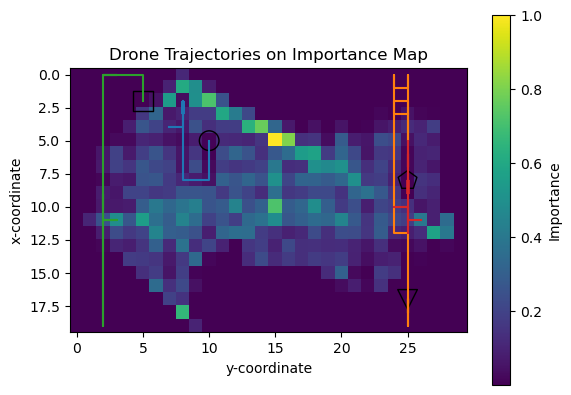

[5.9244864288717505, 1.5026935342501022, -6.217234904931574, 3.2710107550513112]
Time | ep_step:  41 1
[11.943476831540465, 2.8795235292681576, 5.964232888081584, 5.596831103696811]
Time | ep_step:  42 2
[1.5999496374279265, 2.5037556276277098, 7.956303411891938, 4.213528038381671]
Time | ep_step:  43 3
[3.793192160163472, 3.443437203816053, 2.044842690162923, -4.733451022074934]
Time | ep_step:  44 4
[-5.272994461317012, 0.5037509427405923, 4.521492386236787, 0.5018405060498465]
-----------
Episode:  9
Time | ep_step:  45 0
[-0.1419371914118528, 3.1704004530031984, 6.726575147360563, 2.7478488927187508]
Time | ep_step:  46 1
[-0.46178658138960493, -3.135905913738024, 3.8414884004741916, -0.32145483309800826]
Time | ep_step:  47 2
[0.49029319666325843, -0.750863870531735, 3.767018180340529, 6.140925365471787]
Time | ep_step:  48 3
[-0.47622360050678436, 2.4257427822065436, 3.5652831420302395, 6.156169134974478]
Time | ep_step:  49 4
[0.4776891653295612, -2.5462370242901584, 7.220750764

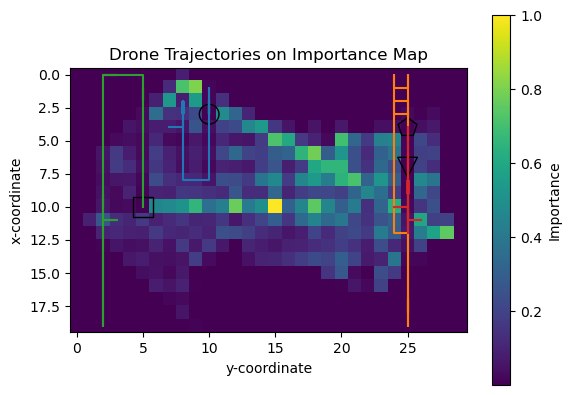

[-1.0115150164533415, 1.9183945113426497, -8.332275286316872, 6.334199246317146]
Time | ep_step:  51 1
[-1.5037013166137025, 4.848338891774418, 8.807798839174213, 2.120492984464591]
Time | ep_step:  52 2
[0.3284639715589563, -8.682596741873775, 1.0366604607552294, 3.722555199478052]
Time | ep_step:  53 3
[-0.13579726232215567, 3.4615558323394224, 5.0148058934137225, 4.23395137808032]
Time | ep_step:  54 4
[2.83450854864903, 4.5960093096256, 2.6216851547360425, -0.7500099999999743]
-----------
Episode:  11
Time | ep_step:  55 0
[1.8896529468428358, 4.0891085161901195, 3.6671293675899506, 4.25]
Time | ep_step:  56 1
[4.404042706266046, -0.875009999999975, 3.152658735249588, 5.125001749999996]
Time | ep_step:  57 2
[8.019921669363974, -4.000008849999977, 4.237564513219355, 4.555878582832123]
Time | ep_step:  58 3
[8.815062542259694, 1.2500014499999967, 3.5609944365876633, 5.059040537070558]
Time | ep_step:  59 4
[-2.6884958967566486, 1.193791195834558, 4.25, 4.8449243141317035]
----------

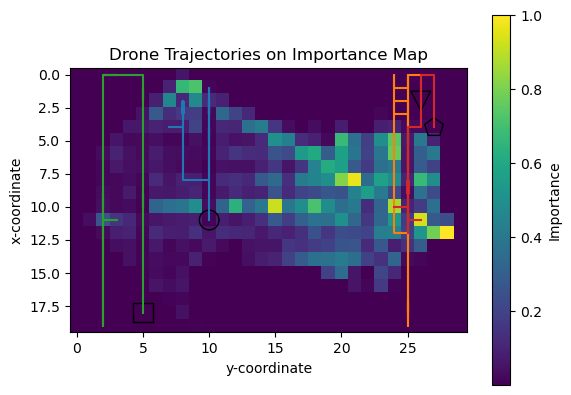

[4.635897988453507, 1.777104301955371, -0.7500099999999743, 12.6750818323344]
Time | ep_step:  61 1
[1.6893939743749802, 7.919972012498498, 4.25, 2.5477590393275023]
Time | ep_step:  62 2
[4.1524384369481595, 4.31428049890697, 5.125001749999996, 6.921568032354117]
Time | ep_step:  63 3
[3.7357915389910663, 5.728070292456076, 4.3750005, 6.143076099455357]
Time | ep_step:  64 4
[4.251805429704547, 8.054190020532165, 4.375000499999999, -16.64577455818653]
-----------
Episode:  13
Time | ep_step:  65 0
[4.242309610166785, 0.5283830407315987, 4.601287917971407, 5.517577214166525]
Time | ep_step:  66 1
[4.25, 1.6382552136170103, 4.560388596968892, 4.803961219266057]
Time | ep_step:  67 2
[-0.7265050595965472, 11.465211720610595, 4.7320755162784005, 4.716801952570677]
Time | ep_step:  68 3
[4.231516013086207, 1.6965480549556688, 4.640343715436757, 13.005979301949765]
Time | ep_step:  69 4
[5.267980250070821, 3.0158064197063474, 3.9702030068729095, 3.215807015309111]
-----------
Episode:  14
T

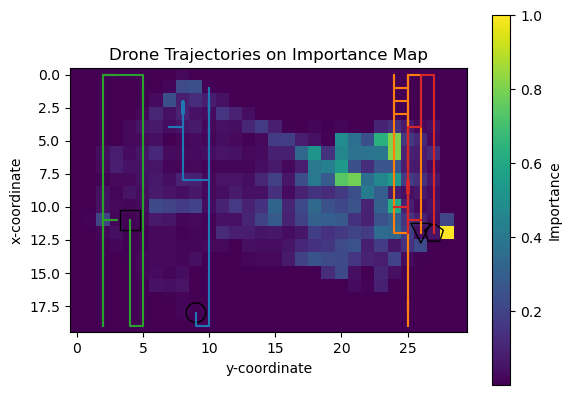

[4.466740425040457, 5.348684747794841, 4.766819937154651, -10.79726684303023]
Time | ep_step:  71 1
[4.452743180140203, 2.4882464211603765, 3.5582720006350432, -3.1219325670802855]
Time | ep_step:  72 2
[5.215062942022684, 3.635567533039091, 5.21639359672554, 3.7501474121415863]
Time | ep_step:  73 3
[3.889132588542566, 4.345912976200783, 4.766331679420546, 10.446520009840103]
Time | ep_step:  74 4
[5.530904243302275, 4.281250312499997, 4.391850938787684, -9.782938764745568]
-----------
Episode:  15
Time | ep_step:  75 0
[3.845940597355365, 4.320625391249999, 3.5049933255650103, -2.907067229507293]
Time | ep_step:  76 1
[7.283553699962797, -0.5018842537499794, 4.319360217625674, 2.7761258243396867]
Time | ep_step:  77 2
[3.269555721431971, 0.7518756287500004, 4.492298864751888, 1.9731807024031882]
Time | ep_step:  78 3
[2.133946671092417, 0.306249783750004, 3.541887310805594, 2.114071301091464]
Time | ep_step:  79 4
[3.449789356882684, 1.0625007374999977, 4.3750005000000005, 1.30162698

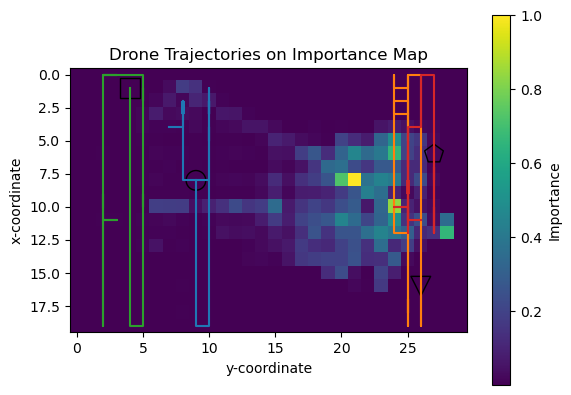

[4.358492789498999, 1.3049477839229395, -0.7500098749999746, 3.2833790870849056]
Time | ep_step:  81 1
[4.323199272546916, 2.2202389992388234, 4.25, 0.7096756307476146]
Time | ep_step:  82 2
[4.378585006521026, 4.923720305597449, 4.25, 2.8995807874474715]
Time | ep_step:  83 3
[4.36981817711523, 3.101499576634297, 9.433839108289021, 3.3825937303276805]
Time | ep_step:  84 4
[4.539450692674842, -3.1773726180404394, 4.987318818814288, 3.63750105]
-----------
Episode:  17
Time | ep_step:  85 0
[5.2589493909238385, 3.7871676309429536, 3.539442044128208, -0.5125076999999807]
Time | ep_step:  86 1
[3.8485276981130454, 4.0842304676335655, 4.110984791070224, 5.66250307499999]
Time | ep_step:  87 2
[-1.1799343672361142, 3.540282656440934, 4.208492557317982, 5.1000016999999955]
Time | ep_step:  88 3
[4.167540710508348, 1.7027641893271594, 4.230349488528901, 4.350000449999999]
Time | ep_step:  89 4
[4.25, 1.6699406223103446, 1.630948031952756, -4.225009074999977]
-----------
Episode:  18
Time | e

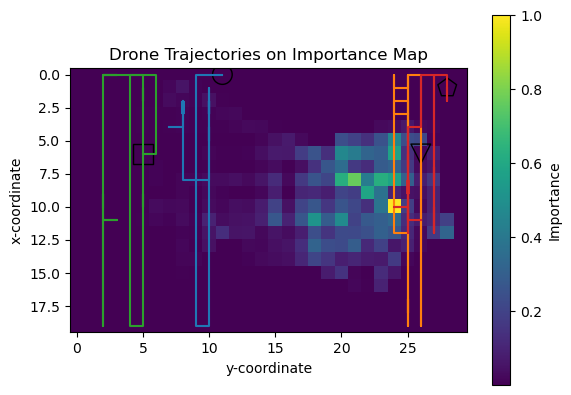

[9.255549107445404, 1.2362379229739362, 0.012331821341036827, 4.100007824999982]
Time | ep_step:  91 1
[4.471839034315167, 0.9800209179051839, 4.2408123015991634, 4.7875013249999965]
Time | ep_step:  92 2
[4.553777943043515, 2.7268597930990928, 4.303709214746477, 4.837370362928388]
Time | ep_step:  93 3
[3.9850845185574144, 3.7210160097916765, 4.2112466717877615, 4.33794880534988]
Time | ep_step:  94 4
[4.221018755575642, 3.947500590000001, 1.3405179004242034, 5.874341823253781]
-----------
Episode:  19
Time | ep_step:  95 0
[4.4608770419145, -0.7750092599999768, -0.7500043249999898, 3.4155609533190736]
Time | ep_step:  96 1
[4.0540434156248475, -2.060006612499982, 0.8750013749999956, 5.398677807673813]
Time | ep_step:  97 2
[4.6980106431472, 1.4025001575000007, 0.7718290839200157, 3.806687355041505]
Time | ep_step:  98 3
[5.971177898172755, 1.8987509949999986, 0.9862820786278997, 6.110901692604449]
Time | ep_step:  99 4
[0.7887374289566657, 3.261255632499985, 4.399476129149255, -6.424

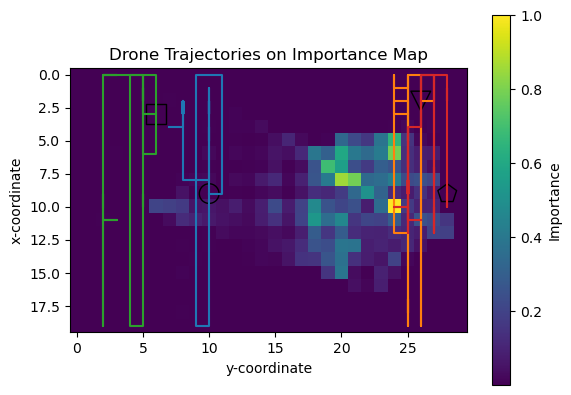

[5.182422650512308, 2.5337886629183597, 0.8875955052759281, 1.5389365202131757]
Time | ep_step:  101 1
[3.8450127436080965, 3.639561851287336, 1.7755689339946878, -1.4498385261961455]
Time | ep_step:  102 2
[3.4356057286058785, 2.374939162849924, 4.676295782559837, 8.043538802146738]
Time | ep_step:  103 3
[-3.6782785433606477, -4.167671246064456, 0.7719783258046764, 2.1940137382936435]
Time | ep_step:  104 4
[1.7213812439935299, 3.7098446713419637, 7.405992535667653, 9.567673794064419]
-----------
Episode:  21
Time | ep_step:  105 0
[-1.7738535875454542, 3.6207163982829105, 4.685541671937562, -2.4005722989531177]
Time | ep_step:  106 1
[4.530913636594778, 2.2002053760737184, 4.367358780578627, 1.3740054004974978]
Time | ep_step:  107 2
[5.42622604719313, 6.1554398202151095, -0.015399277516189613, 1.1796734575277972]
Time | ep_step:  108 3
[4.053280756074401, 4.870872228704387, 4.124999749999999, 4.259159162129717]
Time | ep_step:  109 4
[4.232670964781961, 2.726674688979984, 4.7622822

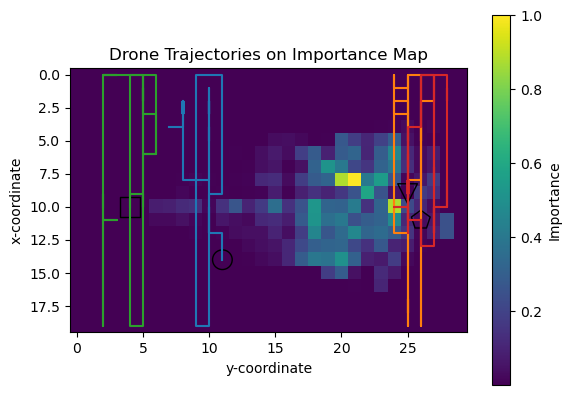

[4.245762572788891, 11.512672072462738, 4.344282109872438, -2.7521838786266755]
Time | ep_step:  111 1
[4.25, -13.316987412702295, 4.191732785641506, 2.0359127187561263]
Time | ep_step:  112 2
[4.25, 2.544099594466385, 4.197639776185839, -1.599259231245892]
Time | ep_step:  113 3
[4.25, 5.925795213412495, 4.215220867145064, 0.6098671423087582]
Time | ep_step:  114 4
[-0.7500099999999743, 11.398428480550649, 4.2388431082183615, 7.388919711960193]
-----------
Episode:  23
Time | ep_step:  115 0
[4.25, -3.3948055846765635, 4.25, 3.9489375873058465]
Time | ep_step:  116 1
[4.251153571073133, 0.8312472774308871, 4.25, 4.171250539999998]
Time | ep_step:  117 2
[9.248856428926842, 4.461217623491332, 4.25, 4.311250415000001]
Time | ep_step:  118 3
[4.25, -3.8816792750869187, -0.7500099999999743, 4.288750077499999]
Time | ep_step:  119 4
[4.25, 4.201749693601042, 4.25, -0.7337599674999745]
-----------
Episode:  24
Time | ep_step:  120 0


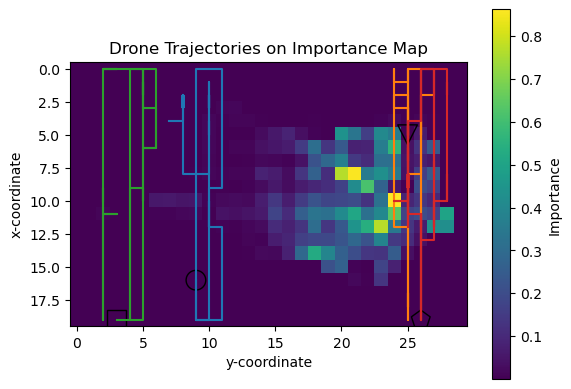

[4.25, 3.343393463473767, 5.125001749999996, 4.25]
Time | ep_step:  121 1
[4.25, -0.9633543334528805, 4.3750005, 4.25]
Time | ep_step:  122 2
[4.262940848322387, 0.4491033879015599, 4.375000499999999, 9.250009999999975]
Time | ep_step:  123 3
[1.555503349741312, 2.1237841596314704, 4.3750005, 4.25]
Time | ep_step:  124 4
[4.634856045416004, 10.101244844358877, 4.375000499999999, 5.653209907155087]
-----------
Episode:  25
Time | ep_step:  125 0
[-0.5813931242382904, 0.9465233034989806, -4.250009124999977, 4.532454349341037]
Time | ep_step:  126 1
[7.466493554501814, -2.3255524751292556, 4.125007874999982, 3.6153874382418683]
Time | ep_step:  127 2
[1.4214335443612425, 3.803496327675877, 4.8125013749999965, 6.704454043880106]
Time | ep_step:  128 3
[4.509980065664358, -4.156096363581716, 4.843875327591592, 7.382322859019041]
Time | ep_step:  129 4
[4.438309966231182, 6.277386384264099, 4.3725299869441585, 1.7384960544295625]
-----------


In [5]:
# Set mode: random, greedy, lstm, nn
mode = 'gru'

pretrained_folder = r'\GRU_13_2_20000iter REAL all files.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)

In [6]:
list_of_perc_gru_1 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_12_2025_22_16_03\list_of_perc_visited.npy')
list_reward_gru_1 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_12_2025_22_16_03\list_of_reward_metric.npy')
list_patrol_gru_1 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_12_2025_22_16_03\list_of_patrol_metric.npy')

In [7]:
list_of_perc_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_13_2025_02_32_03\list_of_perc_visited.npy')
list_reward_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_13_2025_02_32_03\list_of_reward_metric.npy')
list_patrol_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_13_2025_02_32_03\list_of_patrol_metric.npy')

# list_of_perc_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_perc_visited.npy')
# list_reward_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
# list_patrol_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

In [8]:
list_of_perc_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
list_reward_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
list_patrol_greedy = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

# list_of_perc_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
# list_reward_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
# list_patrol_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

In [9]:
list_of_perc_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
list_reward_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
list_patrol_random = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

# list_of_perc_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
# list_reward_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
# list_patrol_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

In [10]:
def percentage_above(graphe1, graphe2):

    graphe1 = np.array(graphe1)
    graphe2 = np.array(graphe2)

    if len(graphe1) != len(graphe2):
        raise ValueError("Les deux graphes doivent avoir la même longueur.")

    nb_au_dessus = np.sum(graphe1 > graphe2)
    pourcentage = (nb_au_dessus / len(graphe1)) * 100

    print(f"GRU est au-dessus de LSTM dans {pourcentage:.2f}% des cas.")
    return pourcentage

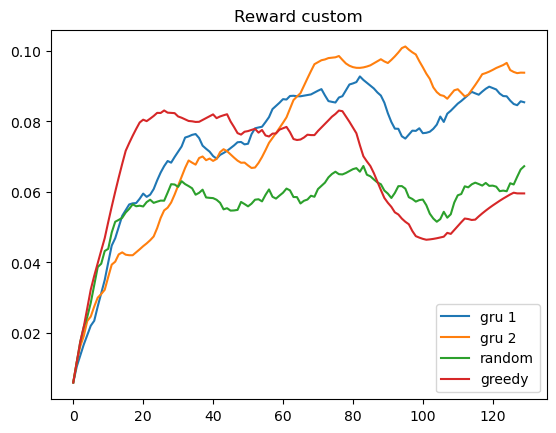

In [11]:
plt.plot(list_patrol_gru_1, label = 'gru 1') # all pickle files
plt.plot(list_patrol_gru_2, label = 'gru 2') # added drones
plt.plot(list_patrol_random, label = 'random')
plt.plot(list_patrol_greedy, label = 'greedy')
plt.title('Reward custom')
plt.legend()

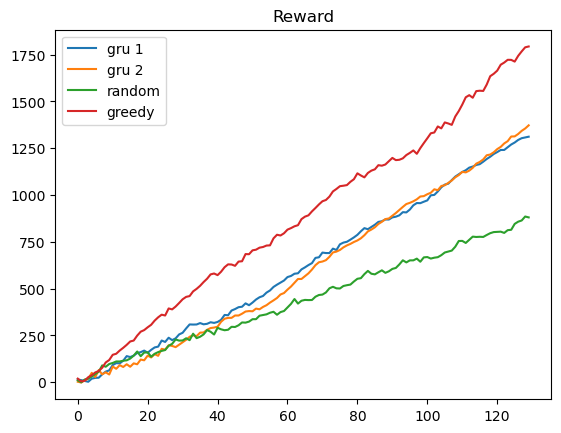

In [12]:
plt.plot(list_reward_gru_1, label = 'gru 1')
plt.plot(list_reward_gru_2, label = 'gru 2')
plt.plot(list_reward_random, label = 'random')
plt.plot(list_reward_greedy, label = 'greedy')
plt.title('Reward')
plt.legend()

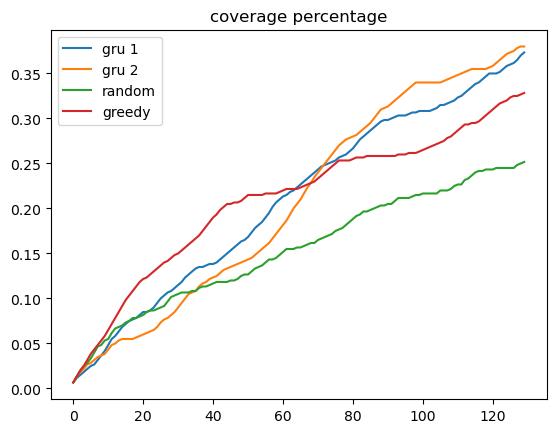

In [13]:
plt.plot(list_of_perc_gru_1, label = 'gru 1')
plt.plot(list_of_perc_gru_2, label = 'gru 2')
plt.plot(list_of_perc_random, label = 'random')
plt.plot(list_of_perc_greedy, label = 'greedy')
plt.title('coverage percentage')
plt.legend()